In [1]:
# Install pip packages
!mkdir ~/tmpdir
!TMPDIR=~/tmpdir python3 -m pip install --upgrade --no-cache-dir "sagemaker<3" pandas numpy matplotlib seaborn scikit-learn "torch==2.6" torchvision boto3

mkdir: cannot create directory ‘/home/ec2-user/tmpdir’: File exists
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.


In [26]:
# Prepare dataset
%cd ~/SageMaker/
! rm -rf dataset/ dataset.zip
!wget -nc -q -O "dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/shaunthesheep/microsoft-catsvsdogs-dataset"

!mkdir dataset -p
!unzip -q -o ./dataset.zip -d ./dataset/
!rm ./dataset/*
!mv ./dataset/PetImages/* ./dataset/
!rm -r ./dataset/PetImages dataset.zip

/home/ec2-user/SageMaker
rm: cannot remove './dataset/PetImages': Is a directory


In [27]:
!rm ./dataset/Cat/666.jpg
!rm ./dataset/Dog/11702.jpg

In [28]:
%cd ./dataset/
!zip -rq ../dataset.zip .
%cd ..

/home/ec2-user/SageMaker/dataset
/home/ec2-user/SageMaker


In [15]:
# Import pip packages
import pandas as pd
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from IPython.display import display
from sagemaker.inputs import TrainingInput
from sagemaker.s3 import S3Uploader

In [16]:
# Set up SageMaker environment
import sagemaker

sess = sagemaker.Session()
bucket = sess.default_bucket()
prefix = "sagemaker"

from sagemaker import get_execution_role

role = get_execution_role()

In [29]:
# Upload dataset zip file to S3
inputs = S3Uploader.upload("dataset.zip", "s3://{}/{}".format(bucket, prefix))

In [22]:
# Find mean, std
_dataset = datasets.ImageFolder(root='./dataset', transform=transforms.ToTensor())
_loader  = DataLoader(_dataset)

mean   = torch.zeros(3)
sq_mean = torch.zeros(3)
n_pixels = 0

with torch.no_grad():
    for images, _ in _loader:
        b, c, h, w = images.shape
        n_pixels += b * h * w
        mean     += images.sum(dim=[0, 2, 3])
        sq_mean  += (images ** 2).sum(dim=[0, 2, 3])

mean  /= n_pixels
std    = (sq_mean / n_pixels - mean ** 2).sqrt()

mean, std

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


(tensor([0.4862, 0.4534, 0.4154]), tensor([0.2626, 0.2559, 0.2586]))

In [40]:
from sagemaker.pytorch import PyTorch

estimator = PyTorch(
    entry_point="train.py",
    framework_version="2.6",
    py_version="py312",
    instance_type="ml.g5.xlarge",
    instance_count=1,
    output_path="s3://{}/{}/output/".format(bucket, prefix),
    checkpoint_s3_uri="s3://{}/{}/checkpoint/".format(bucket, prefix),
    role=role,
    hyperparameters = {
        'epochs': 20,
        'batch_size': 64,
        'lr': 0.001,
        # 'backend': 'gloo'  # distributed
    },
    metric_definitions = [
        {"Name": "train:loss", "Regex": r"Train Loss: ([0-9\.]+)"},
        {"Name": "train:acc",  "Regex": r"Train Acc: ([0-9\.]+)"},
        {"Name": "val:loss",   "Regex": r"Test Loss: ([0-9\.]+)"},
        {"Name": "val:acc",    "Regex": r"Test Acc: ([0-9\.]+)"},
    ],
)

estimator.fit({
    "train": TrainingInput("s3://{}/{}/dataset.zip".format(bucket, prefix)),  # /opt/ml/input/data/train
})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2026-07-01-12-07-11-461


2026-07-01 12:07:11 Starting - Starting the training job...
2026-07-01 12:07:46 Pending - Preparing the instances for training...
2026-07-01 12:08:11 Downloading - Downloading input data......
2026-07-01 12:08:56 Downloading - Downloading the training image........................
2026-07-01 12:13:04 Training - Training image download completed. Training in progress..bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
CUDA compat package should be installed for NVIDIA driver smaller than 560.35.05
Current installed NVIDIA driver version is 570.211.01
Skipping CUDA compat setup as newer NVIDIA driver is installed
2026-07-01 12:13:18,477 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-07-01 12:13:18,496 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-07-01 12:13:18,506 sagemaker_pytorch_container.training INFO     Block until all host 

In [41]:
# Create new model + Update Endpoint
import boto3
import time

sm = boto3.client("sagemaker")

model = estimator.create_model(
    name = f'catsvsdogs-model-{int(time.time())}',
)
model_name = model.name
model._create_sagemaker_model(instance_type="ml.g5.xlarge")

new_config = f'endpoint-configuration-{int(time.time())}'
sm.create_endpoint_config(
    EndpointConfigName=new_config,
    ProductionVariants=[{
        "VariantName": "AllTraffic",
        "ModelName": model_name,
        "InitialInstanceCount": 1,
        "InstanceType": "ml.g5.xlarge"
    }]
)

INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-200148130345/sagemaker/output/pytorch-training-2026-07-01-12-07-11-461/output/model.tar.gz), script artifact (s3://sagemaker-us-east-1-200148130345/pytorch-training-2026-07-01-12-07-11-461/source/sourcedir.tar.gz), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-200148130345/catsvsdogs-model-1782908204/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: catsvsdogs-model-1782908204


{'EndpointConfigArn': 'arn:aws:sagemaker:us-east-1:200148130345:endpoint-config/endpoint-configuration-1782908207',
 'ResponseMetadata': {'RequestId': '876756ad-9751-49f6-8e87-9c2a8c3f4152',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '876756ad-9751-49f6-8e87-9c2a8c3f4152',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '114',
   'date': 'Wed, 01 Jul 2026 12:16:48 GMT'},
  'RetryAttempts': 0}}

In [43]:
# sm.create_endpoint(
#     EndpointName = "catsvsdogs-endpoint",
#     EndpointConfigName = new_config
# )

sm.update_endpoint(
    EndpointName = "catsvsdogs-endpoint",
    EndpointConfigName = new_config
)

{'EndpointArn': 'arn:aws:sagemaker:us-east-1:200148130345:endpoint/catsvsdogs-endpoint',
 'ResponseMetadata': {'RequestId': 'd487bd0e-c48a-482c-a02d-216965bd780b',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'd487bd0e-c48a-482c-a02d-216965bd780b',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '87',
   'date': 'Wed, 01 Jul 2026 12:16:56 GMT'},
  'RetryAttempts': 0}}

In [44]:
# Get class list
CLASSES = _dataset.classes
CLASSES

['Cat', 'Dog']

In [45]:
# Inference test 
import base64, json, boto3
import matplotlib.pyplot as plt
from PIL import Image

client = boto3.client("sagemaker-runtime")
endpoint_name = 'catsvsdogs-endpoint'
image_path = "cat.jpg"

with open(image_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")
response = client.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType="application/json",   #           application/json | text/plain | image/png
    Body=json.dumps({"image": b64}),  # json.dumps({"image": b64}) |        b64 |  f.read()
)

body = json.load(response["Body"])
print(body)
print(CLASSES[body["class_idx"]])

{'class_idx': 0, 'confidence': 0.9831240177154541}
Cat


In [46]:
# Inference test 
import base64, json, boto3

client = boto3.client("sagemaker-runtime")
endpoint_name = 'catsvsdogs-endpoint'
image_path = "dog.jpg"

with open(image_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")
response = client.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType="application/json",   #           application/json | text/plain | image/png
    Body=json.dumps({"image": b64}),  # json.dumps({"image": b64}) |        b64 |  f.read()
)

body = json.load(response["Body"])
print(body)
print(CLASSES[body["class_idx"]])

{'class_idx': 1, 'confidence': 0.9350470304489136}
Dog


{'class_idx': 1, 'confidence': 0.8389925956726074}
Dog


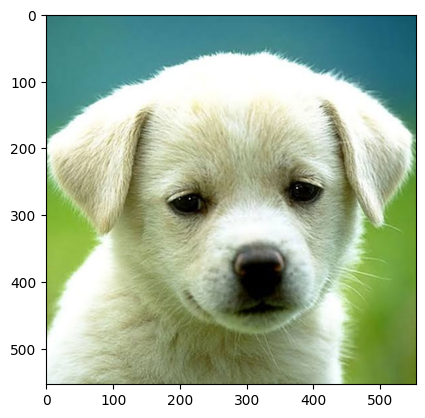

In [51]:
# Inference test (External image) 
import base64, json, boto3

client = boto3.client("sagemaker-runtime")
endpoint_name = 'catsvsdogs-endpoint'
image_path = "dog2.jpg"

img = np.asarray(Image.open('dog2.jpg'))
plt.imshow(img)

with open(image_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")
response = client.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType="application/json",   #           application/json | text/plain | image/png
    Body=json.dumps({"image": b64}),  # json.dumps({"image": b64}) |        b64 |  f.read()
)

body = json.load(response["Body"])
print(body)
print(CLASSES[body["class_idx"]])

{'class_idx': 0, 'confidence': 0.7475258111953735}
Cat


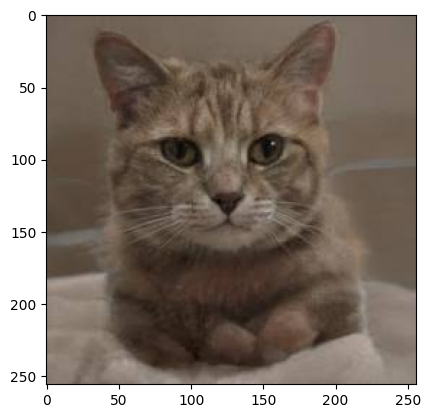

In [50]:
# Inference test (External image) 
import base64, json, boto3

client = boto3.client("sagemaker-runtime")
endpoint_name = 'catsvsdogs-endpoint'
image_path = "cat2.jpg"

img = np.asarray(Image.open('cat2.jpg'))
plt.imshow(img)

with open(image_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")
response = client.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType="application/json",   #           application/json | text/plain | image/png
    Body=json.dumps({"image": b64}),  # json.dumps({"image": b64}) |        b64 |  f.read()
)

body = json.load(response["Body"])
print(body)
print(CLASSES[body["class_idx"]])